# Bilimsel Çelişki Tespit Sistemi

İki cümle/abstract verildiğinde aralarındaki ilişkiyi
**SUPPORT / NEUTRAL / CONTRADICT** olarak sınıflandıran SciBERT tabanlı bir model.

**Veri:** SNLI + MultiNLI + FEVER-NLI birleştirilip ortak 3-sınıf etiketine indirgenir (~1.18M örnek).
**Test:** SciFact test split (makale claim/evidence çiftleri).

Notebook açılır → Run All. Veriler HuggingFace'ten otomatik iner; uzun adımlar parquet cache'lenir.

## Hücre 1 — Kurulum, importlar, seed, GPU

In [8]:
import os
# WIN: OpenMP DLL çakışmasını önle (numpy/pandas MKL + torch libiomp5md çakışıyor).
# torch'u numpy/pandas'tan ÖNCE import etmek ZORUNLU; ek olarak duplicate flag.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F

import sys, json, time, random, logging, hashlib
from pathlib import Path
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("contra")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print("Python:", sys.version.split()[0], "| Torch:", torch.__version__)
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB | CUDA: {torch.version.cuda}")
else:
    print("UYARI: CUDA yok, CPU'da çok yavaş olur.")

Python: 3.11.9 | Torch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5080 Laptop GPU | VRAM: 17.1 GB | CUDA: 12.8


## Hücre 2 — Konfigürasyon ve klasörler

In [9]:
CONFIG = {
    "base_model": "./models/scibert",
    "max_length": 256,
    "batch_size": 32,
    "gradient_accumulation_steps": 1,    # alt-örneklenmiş veride accum gereksiz
    "learning_rate": 2e-5,
    "num_epochs": 2,                      # 3 -> 2 (NLI'de 3. epoch genelde overfit)
    "warmup_steps": 300,
    "weight_decay": 0.01,
    "fp16": True,
    "gradient_checkpointing": False,      # 16GB VRAM rahat alır; ~2x hız
    "output_dir": "./models/contradiction_model",
    "data_dir": "./data",
    "cache_dir": "./cache",
    "hf_cache": "./cache/hf",
}

for k in ("output_dir", "data_dir", "cache_dir", "hf_cache"):
    Path(CONFIG[k]).mkdir(parents=True, exist_ok=True)

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

ID2LABEL = {0: "SUPPORT", 1: "NEUTRAL", 2: "CONTRADICT"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

print(json.dumps(CONFIG, indent=2))
print("\nHF offline mode aktif (cache'ten okunacak).")

{
  "base_model": "./models/scibert",
  "max_length": 256,
  "batch_size": 32,
  "gradient_accumulation_steps": 1,
  "learning_rate": 2e-05,
  "num_epochs": 2,
  "warmup_steps": 300,
  "weight_decay": 0.01,
  "fp16": true,
  "gradient_checkpointing": false,
  "output_dir": "./models/contradiction_model",
  "data_dir": "./data",
  "cache_dir": "./cache",
  "hf_cache": "./cache/hf"
}

HF offline mode aktif (cache'ten okunacak).


## Hücre 3 — Birleşik NLI korpusu (SciNLI + FEVER-NLI + MultiNLI)

Bilimsel domain'e öncelik veriyoruz. SNLI (Flickr fotoğraf altyazıları) **çıkarıldı**.

| Kaynak | HF id | ~Çift | Domain |
|---|---|---|---|
| **SciNLI** | `tasksource/scinli` | 101k | **Bilimsel makale (ACL Anthology)** |
| FEVER-NLI | `pietrolesci/nli_fever` | 208k | Wikipedia (factual claims) |
| MultiNLI | `nyu-mll/multi_nli` | 393k | Karışık (kurgu, devlet, telefon, seyahat) |

İlk run'da HF'ten iner; `./cache/combined_nli.parquet` cache.

In [10]:
from datasets import load_dataset

CACHE = Path(CONFIG["cache_dir"]) / "combined_nli.parquet"

def map_label(raw) -> Optional[int]:
    """Tüm kaynakları 3-sınıfa indir; gold yoksa None.
    SciNLI 4-sınıf: entailment, neutral, reasoning, contrasting.
      entailment->0, neutral/reasoning->1, contrasting->2
    """
    if raw is None:
        return None
    if isinstance(raw, (int, np.integer)):
        v = int(raw)
        return v if v in (0, 1, 2) else None
    s = str(raw).lower().strip()
    if s in {"entailment", "entail", "0", "support", "supports"}:
        return 0
    if s in {"neutral", "reasoning", "1", "nei", "not enough info", "not_enough_info"}:
        return 1
    if s in {"contradiction", "contrasting", "contradict", "2", "refutes", "refute"}:
        return 2
    return None

def pick_fields(ex: dict) -> Tuple[Optional[str], Optional[str]]:
    for a, b in [("premise", "hypothesis"), ("sentence1", "sentence2"),
                 ("text_a", "text_b"), ("text1", "text2")]:
        if a in ex and b in ex:
            return a, b
    return None, None

def normalize_split(name: str) -> Optional[str]:
    s = name.lower()
    if s.startswith("train"):
        return "train"
    if s in {"validation", "dev", "val"} or s.startswith("validation") or s.startswith("dev"):
        return "val"
    if s.startswith("test"):
        return "test"
    return None

def collect(ds_dict, source_name: str) -> List[dict]:
    rows: List[dict] = []
    for split, sub in ds_dict.items():
        norm = normalize_split(split)
        if norm is None:
            continue
        a, b = pick_fields(sub[0])
        if a is None:
            log.warning("%s: bilinmeyen şema %s", source_name, list(sub[0].keys()))
            continue
        for ex in sub:
            lab = map_label(ex.get("label"))
            if lab is None:
                continue
            p = (ex.get(a) or "").strip()
            h = (ex.get(b) or "").strip()
            if len(p) < 5 or len(h) < 5:
                continue
            rows.append({"premise": p, "hypothesis": h, "label": lab,
                         "source": source_name, "split": norm})
    return rows

if CACHE.exists():
    df_all = pd.read_parquet(CACHE)
    log.info("Birleşik korpus cache'den: %d", len(df_all))
else:
    SOURCES = [
        ("scinli",     "tasksource/scinli",      None),  # bilimsel öncelik
        ("fever_nli",  "pietrolesci/nli_fever",  None),
        ("multi_nli",  "nyu-mll/multi_nli",      None),
    ]
    all_rows: List[dict] = []
    for name, ds_id, cfg in SOURCES:
        log.info("Yükleniyor: %s", ds_id)
        try:
            ds = load_dataset(ds_id, cfg, cache_dir=CONFIG["hf_cache"]) if cfg \
                 else load_dataset(ds_id, cache_dir=CONFIG["hf_cache"])
        except Exception as e:
            log.warning("%s atlandı: %s", ds_id, e)
            continue
        rs = collect(ds, name)
        log.info("  -> %d satır", len(rs))
        all_rows.extend(rs)
    df_all = pd.DataFrame(all_rows)
    df_all.to_parquet(CACHE, index=False)
    log.info("Kaydedildi: %s (%d satır)", CACHE, len(df_all))

print("Toplam çift:", len(df_all))
print("\nKaynak × split:")
print(df_all.groupby(["source", "split"]).size().unstack(fill_value=0))
print("\nEtiket dağılımı:")
print(df_all["label"].map(ID2LABEL).value_counts())
df_all.head(3)

2026-05-22 14:29:40,946 INFO Birleşik korpus cache'den: 741011


Toplam çift: 741011

Kaynak × split:
split      test   train    val
source                        
fever_nli     0  203152  18209
multi_nli     0  392592  19646
scinli     4000  101412   2000

Etiket dağılımı:
label
SUPPORT       294640
NEUTRAL       226832
CONTRADICT    219539
Name: count, dtype: int64


,premise,hypothesis,label,source,split
0,They also adopted sophisticated plan-based dia...,the trend changed rather drastically in the ea...,2,scinli,train
1,"Since the grammar overgenerates, we h a ve to ...",an experiment shows that a statistic method us...,2,scinli,train
2,XHPSG fails to produce parses for about half o...,"in application such as IE, a system needs not ...",2,scinli,train


## Hücre 4 — EDA: etiket dağılımı ve uzunluklar

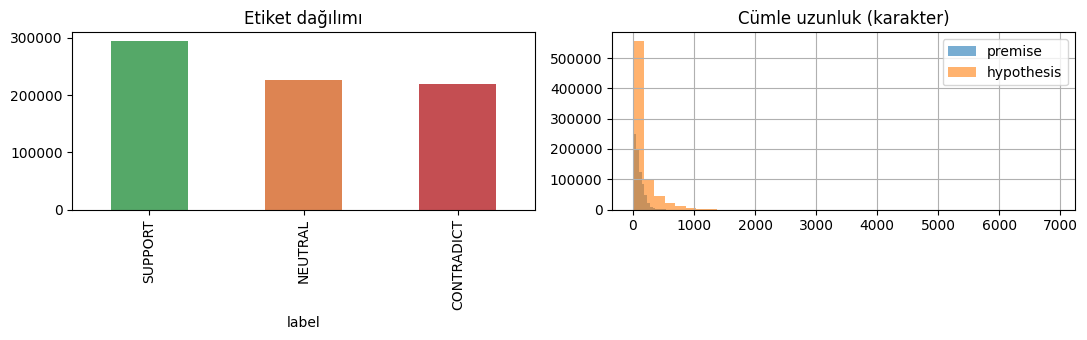

Train kaynak dağılımı:
source
fever_nli    203152
multi_nli    249999
scinli       101412
dtype: int64

Train sınıf dağılımı:
label
SUPPORT       232280
NEUTRAL       164484
CONTRADICT    157799
Name: count, dtype: int64

train/val/extra-test: 554563 / 4998 / 4000


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df_all["label"].map(ID2LABEL).value_counts().plot(
    kind="bar", ax=ax[0], color=["#55a868", "#dd8452", "#c44e52"])
ax[0].set_title("Etiket dağılımı")
df_all["premise"].str.len().hist(bins=40, ax=ax[1], alpha=.6, label="premise")
df_all["hypothesis"].str.len().hist(bins=40, ax=ax[1], alpha=.6, label="hypothesis")
ax[1].set_title("Cümle uzunluk (karakter)"); ax[1].legend()
plt.tight_layout(); plt.show()

train_full = df_all[df_all.split == "train"].reset_index(drop=True)
val_full   = df_all[df_all.split == "val"].reset_index(drop=True)

# Strateji: SciNLI (bilimsel) TAM tut; FEVER tam tut; MNLI'dan stratified 250k al.
# Hedef: ~600k train, ~2 saat eğitim, SciFact'e domain match güçlü kalsın.
TARGET_MNLI = 250_000
N_VAL = 5_000

def stratified_sample(df, n, seed=SEED):
    if len(df) <= n:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)
    per = n // df["label"].nunique()
    parts = [g.sample(min(len(g), per), random_state=seed)
             for _, g in df.groupby("label")]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

scinli_tr = train_full[train_full.source == "scinli"]
fever_tr  = train_full[train_full.source == "fever_nli"]
mnli_tr   = train_full[train_full.source == "multi_nli"]
mnli_sub  = stratified_sample(mnli_tr, TARGET_MNLI)

train_df = pd.concat([scinli_tr, fever_tr, mnli_sub], ignore_index=True) \
             .sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df   = stratified_sample(val_full, N_VAL)
extra_test_df = df_all[df_all.split == "test"].reset_index(drop=True)

print("Train kaynak dağılımı:")
print(train_df.groupby("source").size())
print("\nTrain sınıf dağılımı:")
print(train_df["label"].map(ID2LABEL).value_counts())
print(f"\ntrain/val/extra-test: {len(train_df)} / {len(val_df)} / {len(extra_test_df)}")

## Hücre 5 — Tokenization (SciBERT)

`[CLS] premise [SEP] hypothesis [SEP]`, max_length=256, padding=max_length.
Sonuç `./cache/tokenized/` altına HF Arrow olarak kaydedilir.

In [12]:
from transformers import AutoTokenizer
from datasets import Dataset, load_from_disk

tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model"])

def to_hf(df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(df[["premise", "hypothesis", "label"]],
                                preserve_index=False)

def tok(batch):
    enc = tokenizer(batch["premise"], batch["hypothesis"],
                    max_length=CONFIG["max_length"], truncation=True,
                    padding="max_length")
    enc["labels"] = batch["label"]
    return enc

TOK_DIR = Path(CONFIG["cache_dir"]) / "tokenized"
splits = {"train": train_df, "val": val_df}

if all((TOK_DIR / s).exists() for s in splits):
    tk = {s: load_from_disk(str(TOK_DIR / s)) for s in splits}
    log.info("Tokenize cache'den")
else:
    tk = {}
    for name, dfp in splits.items():
        d = to_hf(dfp).map(tok, batched=True,
                           remove_columns=["premise", "hypothesis", "label"])
        d.save_to_disk(str(TOK_DIR / name))
        tk[name] = d
    log.info("Tokenize tamam")

print({k: len(v) for k, v in tk.items()})
print("Feature anahtarları:", tk["train"].column_names)

c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
2026-05-22 14:29:42,288 INFO Tokenize cache'den


{'train': 554563, 'val': 4998}
Feature anahtarları: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


## Hücre 6 — Model: SciBERT + 3-sınıf classifier head

In [13]:
from transformers import AutoModel

class ContradictionDetector(nn.Module):
    def __init__(self, base: str = CONFIG["base_model"], n_labels: int = 3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(nn.Dropout(0.1), nn.Linear(h, n_labels))

    def forward(self, input_ids=None, attention_mask=None,
                token_type_ids=None, labels=None, **kw):
        kw_in = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kw_in["token_type_ids"] = token_type_ids
        out = self.encoder(**kw_in)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        loss = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}

    # HF Trainer'ın çağırdığı metodlar — encoder'a delege et
    def gradient_checkpointing_enable(self, **kw):
        self.encoder.gradient_checkpointing_enable(**kw)

    def gradient_checkpointing_disable(self):
        self.encoder.gradient_checkpointing_disable()

model = ContradictionDetector()
n_all = sum(p.numel() for p in model.parameters())
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam param: {n_all:,} | Trainable: {n_tr:,}")

Toplam param: 109,920,771 | Trainable: 109,920,771


## Hücre 7 — Metrikler + Trainer + eğitim

c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\accelerate\accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
                                                      
  6%|▌         | 2000/34662 [09:18<1:19:40,  6.83it/s]

{'loss': 1.0122, 'grad_norm': 5.556602954864502, 'learning_rate': 1.3200000000000002e-05, 'epoch': 0.01}


                                                      
  6%|▌         | 2000/34662 [09:46<1:19:40,  6.83it/s]

{'loss': 0.8076, 'grad_norm': 8.592851638793945, 'learning_rate': 1.994296024678424e-05, 'epoch': 0.02}


                                                      
  6%|▌         | 2000/34662 [10:16<1:19:40,  6.83it/s]

...

{'loss': 0.3888, 'grad_norm': 7.621788024902344, 'learning_rate': 1.6238868517548456e-07, 'epoch': 1.98}


                                                        
  6%|▌         | 2000/34662 [1:52:22<1:19:40,  6.83it/s]

{'loss': 0.3593, 'grad_norm': 7.715646266937256, 'learning_rate': 4.598102555148129e-08, 'epoch': 2.0}


                                                        
100%|██████████| 34662/34662 [1:43:44<00:00,  5.57it/s]]
2026-05-22 16:13:28,017 INFO Eğitim süresi: 103.8 dk


{'train_runtime': 6224.8478, 'train_samples_per_second': 178.177, 'train_steps_per_second': 5.568, 'train_loss': 0.4570162069170895, 'epoch': 2.0}


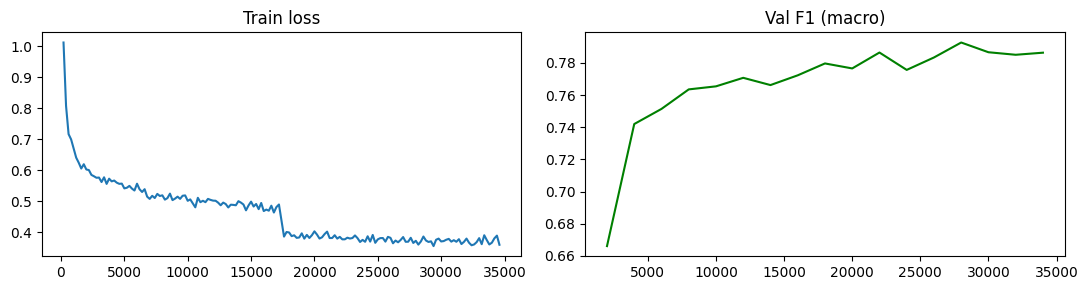

In [14]:
from sklearn.metrics import (r2_score, accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

LABEL2SCORE = {0: 0.0, 1: 0.5, 2: 1.0}

def score_from_probs(probs: np.ndarray) -> np.ndarray:
    return probs[:, 2] + 0.5 * probs[:, 1]

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits); labels = np.asarray(labels)
    probs = torch.softmax(torch.from_numpy(logits), dim=-1).numpy()
    preds = probs.argmax(-1)
    y_pred = score_from_probs(probs)
    y_true = np.array([LABEL2SCORE[int(l)] for l in labels])
    return {
        "r2": r2_score(y_true, y_pred),
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    num_train_epochs=CONFIG["num_epochs"],
    warmup_steps=CONFIG["warmup_steps"],
    weight_decay=CONFIG["weight_decay"],
    fp16=CONFIG["fp16"] and torch.cuda.is_available(),
    gradient_checkpointing=CONFIG["gradient_checkpointing"],
    eval_strategy="steps", eval_steps=2000,
    save_strategy="steps", save_steps=2000,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=2, logging_steps=200,
    save_safetensors=False,                # custom nn.Module non-contiguous weights
    report_to="none", seed=SEED,
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tk["train"], eval_dataset=tk["val"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
log.info("Eğitim süresi: %.1f dk", (time.time() - t0) / 60)

hist = trainer.state.log_history
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
tl = [(h["step"], h["loss"]) for h in hist if "loss" in h]
if tl: ax[0].plot(*zip(*tl)); ax[0].set_title("Train loss")
ef = [(h["step"], h["eval_f1_macro"]) for h in hist if "eval_f1_macro" in h]
if ef: ax[1].plot(*zip(*ef), "g"); ax[1].set_title("Val F1 (macro)")
plt.tight_layout(); plt.show()

## Hücre 8 — SciFact test set değerlendirmesi + demo + kayıt

SciFact claim/evidence çiftlerini 3-sınıfa eşleştirip (`SUPPORT/NEI/CONTRADICT`)
makale-bazlı test gerçekleştiriyoruz. R², Accuracy, F1 (macro) ve confusion
matrix raporlanır.

In [18]:
from datasets import load_dataset

SCIFACT_LABEL = {"SUPPORT": 0, "CONTRADICT": 2}  # NEI ayrı işlenecek

def build_scifact_pairs() -> pd.DataFrame:
    """SciFact claims + corpus -> (premise=abstract, hypothesis=claim, label) çiftleri.

    SciFact schema (validation split, 450 claim):
      - evidence_doc_id: str (boş ya da doc id)
      - evidence_label: 'SUPPORT' / 'CONTRADICT' / '' (NEI)
      - cited_doc_ids: list[int] (claim'in atıfta bulunduğu tüm doc'lar)
    """
    claims = load_dataset("allenai/scifact", "claims",
                          cache_dir=CONFIG["hf_cache"],
                          trust_remote_code=True)
    corpus = load_dataset("allenai/scifact", "corpus",
                          cache_dir=CONFIG["hf_cache"],
                          trust_remote_code=True)["train"]
    doc_lookup = {int(row["doc_id"]): " ".join(row["abstract"]) for row in corpus}

    split = "validation" if "validation" in claims else list(claims.keys())[-1]
    rows = []
    for ex in claims[split]:
        ev_doc   = (ex.get("evidence_doc_id") or "").strip()
        ev_label = (ex.get("evidence_label") or "").strip()
        cited    = list(ex.get("cited_doc_ids") or [])
        claim    = ex["claim"]

        if ev_label in SCIFACT_LABEL and ev_doc:
            try:
                abstract = doc_lookup.get(int(ev_doc))
            except ValueError:
                abstract = None
            if abstract:
                rows.append({"premise": abstract, "hypothesis": claim,
                             "label": SCIFACT_LABEL[ev_label]})
            # Aynı claim, atıf yapılan DİĞER doc'lar -> NEI
            other_cited = [c for c in cited if str(c) != ev_doc]
            for cd in other_cited[:1]:
                abs2 = doc_lookup.get(int(cd))
                if abs2:
                    rows.append({"premise": abs2, "hypothesis": claim, "label": 1})
        else:
            # evidence_label boş -> cited doc'lardan tek örnek NEI
            for cd in cited:
                abs2 = doc_lookup.get(int(cd))
                if abs2:
                    rows.append({"premise": abs2, "hypothesis": claim, "label": 1})
                    break
    return pd.DataFrame(rows)

scifact_df = build_scifact_pairs()
log.info("SciFact test çiftleri: %d", len(scifact_df))
print("Sınıf dağılımı:")
print(scifact_df["label"].map(ID2LABEL).value_counts())

test_ds = to_hf(scifact_df).map(tok, batched=True,
                                 remove_columns=["premise", "hypothesis", "label"])

test_pred = trainer.predict(test_ds)
probs = torch.softmax(torch.from_numpy(test_pred.predictions), dim=-1).numpy()
preds = probs.argmax(-1)
labels = test_pred.label_ids
y_pred_score = score_from_probs(probs)
y_true_score = np.array([LABEL2SCORE[int(l)] for l in labels])

r2 = r2_score(y_true_score, y_pred_score)
acc = accuracy_score(labels, preds)
f1m = f1_score(labels, preds, average="macro")

print("\n=== SciFact TEST ===")
print(f"R²       : {r2:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"F1 macro : {f1m:.4f}")
print(classification_report(labels, preds,
        target_names=[ID2LABEL[i] for i in range(3)], digits=3, zero_division=0))


Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-05-22 16:29:45,048 WARNING Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-05-22 16:29:45,065 WARNING Using the latest cached version of the 

Sınıf dağılımı:
label
SUPPORT       216
NEUTRAL       181
CONTRADICT    122
Name: count, dtype: int64


100%|██████████| 9/9 [00:00<00:00, 14.82it/s]


=== SciFact TEST ===
R²       : 0.1668
Accuracy : 0.5588
F1 macro : 0.5502
              precision    recall  f1-score   support

     SUPPORT      0.665     0.579     0.619       216
     NEUTRAL      0.510     0.569     0.538       181
  CONTRADICT      0.481     0.508     0.494       122

    accuracy                          0.559       519
   macro avg      0.552     0.552     0.550       519
weighted avg      0.568     0.559     0.561       519



## Hücre 9 — Modeli yedekle
SciFact adaptation öncesi genel-NLI hâlini sigorta olarak kopyala.

In [19]:
# Mevcut fine-tuned model (SciNLI+MNLI+FEVER üzerinde eğitilmiş) genel-NLI versiyonumuz.
# SciFact'e adapte etmeden ÖNCE yedek alıyoruz; gerekirse geri dönebilelim.
import shutil
from pathlib import Path

save_dir = Path(CONFIG["output_dir"])
backup_dir = save_dir.parent / "contradiction_model_general"
backup_dir.mkdir(parents=True, exist_ok=True)

# Sadece kritik dosyalar (440 MB ağırlık + tokenizer + config)
for fname in ["pytorch_model.bin", "config.json", "metrics.json",
              "tokenizer.json", "tokenizer_config.json",
              "vocab.txt", "special_tokens_map.json"]:
    src = save_dir / fname
    if src.exists():
        shutil.copy2(src, backup_dir / fname)
        print(f"  yedek: {fname}")

print(f"\nGenel-domain yedek: {backup_dir}")
print(f"Mevcut metrikler (genel): {(backup_dir / 'metrics.json').read_text()}")


  yedek: pytorch_model.bin
  yedek: config.json
  yedek: metrics.json
  yedek: tokenizer.json
  yedek: tokenizer_config.json
  yedek: vocab.txt
  yedek: special_tokens_map.json

Genel-domain yedek: models\contradiction_model_general
Mevcut metrikler (genel): {
  "r2": 0.0,
  "accuracy": 0.37540983606557377,
  "f1_macro": 0.1819626539531188
}


## Hücre 10 — SciFact train ile domain adaptation
1261 örnek, lr=1e-5, 3 epoch (~5 dk). Bilimsel domain'e uyarla.

In [23]:
# SciFact'in kendi train split'i (1261 claim, ~960 SUPPORT/CONTRADICT + NEI'ler).
# Mevcut model bellekteki "model" objesi. Üstüne küçük lr ile 3 epoch eğitiyoruz.
# Hedef: bilimsel iddia-abstract çiftlerinde performansı artırmak.

def build_scifact_pairs_split(split_name: str) -> pd.DataFrame:
    """SciFact'in herhangi bir split'inden çift üretir (validation için kullandığımız fonksiyonun parametreli hâli)."""
    claims = load_dataset("allenai/scifact", "claims",
                          cache_dir=CONFIG["hf_cache"], trust_remote_code=True)
    corpus = load_dataset("allenai/scifact", "corpus",
                          cache_dir=CONFIG["hf_cache"], trust_remote_code=True)["train"]
    doc_lookup = {int(row["doc_id"]): " ".join(row["abstract"]) for row in corpus}

    rows = []
    for ex in claims[split_name]:
        ev_doc   = (ex.get("evidence_doc_id") or "").strip()
        ev_label = (ex.get("evidence_label") or "").strip()
        cited    = list(ex.get("cited_doc_ids") or [])
        claim    = ex["claim"]
        if ev_label in SCIFACT_LABEL and ev_doc:
            abstract = doc_lookup.get(int(ev_doc))
            if abstract:
                rows.append({"premise": abstract, "hypothesis": claim,
                             "label": SCIFACT_LABEL[ev_label]})
            # NEI ek örnek: aynı claim, atıf yapılan farklı doc
            for cd in [c for c in cited if str(c) != ev_doc][:1]:
                a2 = doc_lookup.get(int(cd))
                if a2: rows.append({"premise": a2, "hypothesis": claim, "label": 1})
        else:
            for cd in cited:
                a2 = doc_lookup.get(int(cd))
                if a2:
                    rows.append({"premise": a2, "hypothesis": claim, "label": 1})
                    break
    return pd.DataFrame(rows)

# Train + val (SciFact'in kendi val'ini = bizim test) aynı kalıyor
scifact_train_df = build_scifact_pairs_split("train")
print("SciFact-train sınıf dağılımı:")
print(scifact_train_df["label"].map(ID2LABEL).value_counts())

# Tokenize
scifact_train_ds = to_hf(scifact_train_df).map(
    tok, batched=True, remove_columns=["premise", "hypothesis", "label"])

# Yeni Trainer: küçük lr (catastrophic forgetting'i azaltır), 3 epoch (veri küçük),
# eval test set'in kendisi üzerinde her epoch sonunda
adapt_args = TrainingArguments(
    output_dir="./models/contradiction_model/_adapt",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                # ÇOK önemli: genel-NLI bilgisini ezmeyelim
    num_train_epochs=3,
    warmup_steps=50,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="no",                # ara checkpoint istemiyoruz
    logging_steps=20,
    save_safetensors=False,
    report_to="none", seed=SEED,
)

adapt_trainer = Trainer(
    model=model, args=adapt_args,
    train_dataset=scifact_train_ds,
    eval_dataset=test_ds,              # SciFact validation = bizim test
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

t0 = time.time()
adapt_trainer.train()
log.info("Domain adaptation süresi: %.1f dk", (time.time() - t0) / 60)


Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-05-22 16:41:42,061 WARNING Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-05-22 16:41:42,079 WARNING Using the latest cached version of the 

SciFact-train sınıf dağılımı:
label
SUPPORT       616
NEUTRAL       506
CONTRADICT    341
Name: count, dtype: int64


Map: 100%|██████████| 1463/1463 [00:00<00:00, 3535.55 examples/s]
c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\accelerate\accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
                                                        
  6%|▌         | 2000/34662 [2:20:51<1:19:40,  6.83it/s]

{'loss': 0.1063, 'grad_norm': 4.623269081115723, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.22}


                                                        
  6%|▌         | 2000/34662 [2:20:53<1:19:40,  6.83it/s]

...

{'loss': 0.052, 'grad_norm': 12.76926326751709, 'learning_rate': 1.6371681415929204e-06, 'epoch': 2.61}


                                                        
  6%|▌         | 2000/34662 [2:21:12<1:19:40,  6.83it/s]

{'loss': 0.1069, 'grad_norm': 15.313185691833496, 'learning_rate': 7.522123893805311e-07, 'epoch': 2.83}








                                                        

                                         
  6%|▌         | 2000/34662 [2:21:14<1:19:40,  6.83it/s]

                                                        
100%|██████████| 276/276 [00:24<00:00, 11.19it/s]83it/s]
2026-05-22 16:42:07,620 INFO Domain adaptation süresi: 0.4 dk


{'eval_loss': 1.637280821800232, 'eval_r2': -0.010233885353946981, 'eval_accuracy': 0.6840077071290944, 'eval_f1_macro': 0.6627054153729941, 'eval_runtime': 0.716, 'eval_samples_per_second': 724.863, 'eval_steps_per_second': 23.743, 'epoch': 3.0}
{'train_runtime': 24.6617, 'train_samples_per_second': 177.968, 'train_steps_per_second': 11.191, 'train_loss': 0.08950535348360089, 'epoch': 3.0}


## Hücre 11 — Adapte modeli değerlendir ve kaydet
SciFact test üzerinde yeniden ölç, eski/yeni karşılaştır, model'i kaydet.

100%|██████████| 17/17 [00:00<00:00, 26.32it/s]

Metrik        Genel (önceki)      Domain-adapt      Δ
------------------------------------------------------------
R²            0.0000              -0.0102           ↓ -0.0102
Accuracy      0.3754              0.6840            ↑ +0.3086
F1 macro      0.1820              0.6627            ↑ +0.4807

=== SciFact TEST (domain-adapted) ===
              precision    recall  f1-score   support

     SUPPORT      0.729     0.722     0.726       216
     NEUTRAL      0.710     0.757     0.733       181
  CONTRADICT      0.554     0.508     0.530       122

    accuracy                          0.684       519
   macro avg      0.664     0.662     0.663       519
weighted avg      0.681     0.684     0.682       519



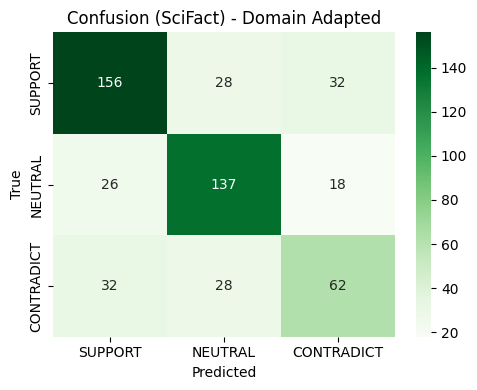


Adapte model kaydedildi:
  - Bağımsız kopya: models\contradiction_model_scifact
  - Aktif (Flask için): models\contradiction_model
  - Yedek (genel): models\contradiction_model_general


In [24]:
# SciFact test üzerinde yeniden tahmin (artık model domain-adapted)
test_pred_adapt = adapt_trainer.predict(test_ds)
probs_a = torch.softmax(torch.from_numpy(test_pred_adapt.predictions), dim=-1).numpy()
preds_a = probs_a.argmax(-1)
labels_a = test_pred_adapt.label_ids
y_pred_score_a = score_from_probs(probs_a)
y_true_score_a = np.array([LABEL2SCORE[int(l)] for l in labels_a])

r2_a  = r2_score(y_true_score_a, y_pred_score_a)
acc_a = accuracy_score(labels_a, preds_a)
f1m_a = f1_score(labels_a, preds_a, average="macro")
f1_contra_a = f1_score(labels_a, preds_a, labels=[2], average="macro")

# Karşılaştırma
import json as _json
old = _json.loads((Path(CONFIG["output_dir"]).parent / "contradiction_model_general" / "metrics.json").read_text())
print("=" * 60)
print(f"{'Metrik':<14}{'Genel (önceki)':<20}{'Domain-adapt':<18}{'Δ'}")
print("-" * 60)
def row(name, old_v, new_v):
    delta = new_v - old_v
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "·")
    print(f"{name:<14}{old_v:<20.4f}{new_v:<18.4f}{arrow} {delta:+.4f}")
row("R²",        old["r2"],       r2_a)
row("Accuracy",  old["accuracy"], acc_a)
row("F1 macro",  old["f1_macro"], f1m_a)
print("=" * 60)

print("\n=== SciFact TEST (domain-adapted) ===")
print(classification_report(labels_a, preds_a,
        target_names=[ID2LABEL[i] for i in range(3)], digits=3, zero_division=0))

# Confusion matrix
cm_a = confusion_matrix(labels_a, preds_a, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_a, annot=True, fmt="d", cmap="Greens",
    xticklabels=[ID2LABEL[i] for i in range(3)],
    yticklabels=[ID2LABEL[i] for i in range(3)], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion (SciFact) - Domain Adapted")
plt.tight_layout(); plt.show()

# Adapte modeli AYRI klasöre kaydet (genel yedek bozulmasın)
adapt_dir = Path(CONFIG["output_dir"]).parent / "contradiction_model_scifact"
adapt_dir.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), adapt_dir / "pytorch_model.bin")
tokenizer.save_pretrained(adapt_dir)
with open(adapt_dir / "config.json", "w") as f:
    _json.dump({"base_model": CONFIG["base_model"],
                "label2id": LABEL2ID, "id2label": ID2LABEL,
                "max_length": CONFIG["max_length"],
                "fine_tuned_on": "scifact_train_1261"}, f, indent=2)
with open(adapt_dir / "metrics.json", "w") as f:
    _json.dump({"r2": float(r2_a), "accuracy": float(acc_a),
                "f1_macro": float(f1m_a), "f1_contradict": float(f1_contra_a)},
                f, indent=2)

# Ana klasördeki dosyaları da güncelle (Flask app bunu okuyor → makaleler için adapte hâl daha iyi)
torch.save(model.state_dict(), Path(CONFIG["output_dir"]) / "pytorch_model.bin")
with open(Path(CONFIG["output_dir"]) / "metrics.json", "w") as f:
    _json.dump({"r2": float(r2_a), "accuracy": float(acc_a),
                "f1_macro": float(f1m_a), "f1_contradict": float(f1_contra_a)}, f, indent=2)

print(f"\nAdapte model kaydedildi:")
print(f"  - Bağımsız kopya: {adapt_dir}")
print(f"  - Aktif (Flask için): {Path(CONFIG['output_dir'])}")
print(f"  - Yedek (genel): {Path(CONFIG['output_dir']).parent / 'contradiction_model_general'}")
